d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch [1/10], Loss Train: 1.7031, Loss Val: 1.3696
Epoch [2/10], Loss Train: 1.3615, Loss Val: 1.1445
Epoch [3/10], Loss Train: 1.2089, Loss Val: 1.0237
Epoch [4/10], Loss Train: 1.1030, Loss Val: 0.9262
Epoch [5/10], Loss Train: 1.0366, Loss Val: 0.8522
Epoch [6/10], Loss Train: 0.9865, Loss Val: 0.8269
Epoch [7/10], Loss Train: 0.9424, Loss Val: 0.7951
Epoch [8/10], Loss Train: 0.9133, Loss Val: 0.7751
Epoch [9/10], Loss Train: 0.8850, Loss Val: 0.7775
Epoch [10/10], Loss Train: 0.8682, Loss Val: 0.7751


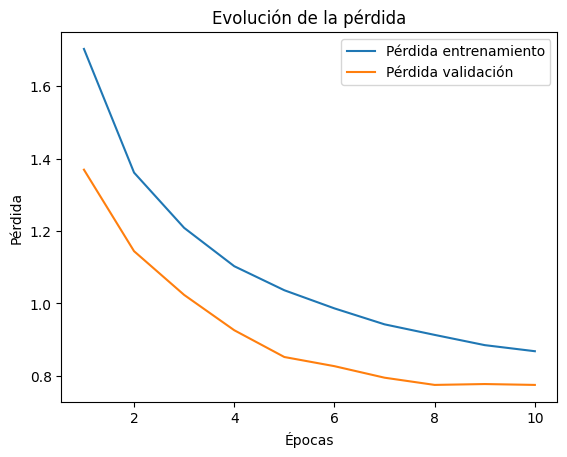

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =========================
# 1. Transformaciones
# =========================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

# =========================
# 2. Datasets
# =========================

trainset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# =========================
# 3. DataLoaders
# =========================

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

# =========================
# 4. Modelo CNN mejorado
# =========================

class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Bloque 1
        x = torch.relu(self.conv1(x))
        x = self.pool(x)   # 32x32 -> 16x16

        # Bloque 2
        x = torch.relu(self.conv2(x))
        x = self.pool(x)   # 16x16 -> 8x8

        # Bloque 3
        x = torch.relu(self.conv3(x))
        x = self.pool(x)   # 8x8 -> 4x4

        # Aplanado
        x = torch.flatten(x, 1)

        # Clasificación
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# =========================
# 5. Inicialización
# =========================

model = BetterCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =========================
# 6. Entrenamiento
# =========================

train_loss = []
val_loss = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_loss.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    epoch_val_loss = val_running_loss / len(testloader)
    val_loss.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss Train: {epoch_train_loss:.4f}, Loss Val: {epoch_val_loss:.4f}')

# =========================
# 7. Gráfica
# =========================

plt.plot(range(1, num_epochs + 1), train_loss, label='Pérdida entrenamiento')
plt.plot(range(1, num_epochs + 1), val_loss, label='Pérdida validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Evolución de la pérdida')
plt.legend()
plt.show()